# Model Validation Notebook

In [14]:
import sys
from pathlib import Path
import torch
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def find_project_root(start_path: Path, required_dir: str = "src") -> Path:
    current = start_path.resolve()
    while True:
        if (current / required_dir).exists():
            return current
        if current.parent == current:
            raise FileNotFoundError(f"Cannot find project root containing '{required_dir}'")
        current = current.parent

PROJECT_ROOT = find_project_root(Path.cwd(), required_dir="src")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.datasets.multimodal_raw_dataset import MultiModalRawDataset, multimodal_raw_collate_fn
from src.models.multimodal.multimodal_text_guided_pvd_infonce_supcon import MultimodalTextGuidedPVDInfoNCESupCon
from src.models.losses.wrapper_loss import InfoNCESupConLoss
from src.evaluation.validation_metrics import (
    bootstrap_classification_metrics,
    class_distribution_from_labels,
    low_support_warnings,
)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /media/data3/users/luongdth/MulCo-PlantNet


## 1. Tải Checkpoint & Khôi phục Cấu hình (Config)

In [15]:
# Thư mục lưu mô hình của bạn
ARCHIVE_DIR = "archive/text_guided_infonce_supcon_multihead_attention_pvd"
CHECKPOINT_NAME = "best_model.pt"

ckpt_path = PROJECT_ROOT / ARCHIVE_DIR / CHECKPOINT_NAME
print(f"Loading checkpoint from: {ckpt_path}")

if not ckpt_path.exists():
    raise FileNotFoundError(f"Không tìm thấy file trọng số tại: {ckpt_path}")

# Load checkpoint lên CPU trước để tránh đầy VRAM
checkpoint = torch.load(ckpt_path, map_location="cpu")
config = checkpoint["config"]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used for evaluation: {device}")
print(f"Model was trained up to epoch: {checkpoint.get('epoch', 'Unknown')}")
print(f"Best Validation Metric (Accuracy) during training: {checkpoint.get('best_metric', 'Unknown')}")

Loading checkpoint from: /media/data3/users/luongdth/MulCo-PlantNet/archive/text_guided_infonce_supcon_multihead_attention_pvd/best_model.pt
Device used for evaluation: cuda
Model was trained up to epoch: 30
Best Validation Metric (Accuracy) during training: 0.7855308219178082


## 2. Khởi tạo Dataset & DataLoader

In [16]:
def build_val_transform(img_size: int):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

val_transform = build_val_transform(config["data"]["img_size"])

# Override đường dẫn val để luôn dùng bộ validation v2
val_image_root = PROJECT_ROOT / "data" / "processed" / "PlantDoc_multimodal_validation_v2" / "images"
val_caption_root = PROJECT_ROOT / "data" / "processed" / "PlantDoc_multimodal_validation_v2" / "captions"

print("Using image root:", val_image_root)
print("Using caption root:", val_caption_root)

val_dataset = MultiModalRawDataset(
    image_root=val_image_root,
    caption_root=val_caption_root,
    transform=val_transform,
    use_depth_suppressed=False,
    strict_caption_match=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config["training"].get("batch_size", 8),
    shuffle=False,
    num_workers=config["training"].get("num_workers", 4),
    pin_memory=torch.cuda.is_available(),
    collate_fn=multimodal_raw_collate_fn,
)

print(f"Validation samples: {len(val_dataset)}")

[WARN] Validation path trong checkpoint không tồn tại, dùng fallback test split.
[WARN] Missing image root: /media/data3/users/luongdth/MulCo-PlantNet/data/AIDG/dataset_PlantDoc/images/validation
[WARN] Missing caption root: /media/data3/users/luongdth/MulCo-PlantNet/data/AIDG/captions_LLaVA/validation
Using image root: /media/data3/users/luongdth/MulCo-PlantNet/data/AIDG/dataset_PlantDoc/images/test
Using caption root: /media/data3/users/luongdth/MulCo-PlantNet/data/AIDG/captions_LLaVA/test
[MultiModalRawDataset] Total selected images: 236
[MultiModalRawDataset] Valid samples: 236
[MultiModalRawDataset] Skipped missing caption: 0
[MultiModalRawDataset] Skipped invalid caption: 0
[MultiModalRawDataset] Num classes: 27
[MultiModalRawDataset] class_to_idx: {'Apple_Scab_Leaf': 0, 'Apple_leaf': 1, 'Apple_rust_leaf': 2, 'Bell_pepper_leaf': 3, 'Bell_pepper_leaf_spot': 4, 'Blueberry_leaf': 5, 'Cherry_leaf': 6, 'Corn_Gray_leaf_spot': 7, 'Corn_leaf_blight': 8, 'Corn_rust_leaf': 9, 'Peach_leaf':

## 3. Nạp Model & Trọng số

In [17]:
model = MultimodalTextGuidedPVDInfoNCESupCon(
    num_classes=config["model"]["num_classes"],
    clip_model_name=config["model"]["clip_model_name"],
    clip_pretrained=config["model"]["clip_pretrained"],
    text_input_dim=config["model"]["text_input_dim"],
    image_input_dim=config["model"]["image_input_dim"],
    proj_dim=config["model"]["proj_dim"],
    proj_hidden_dim=config["model"]["proj_hidden_dim"],
    pvd_hidden_dim=config["model"]["pvd_hidden_dim"],
    cls_hidden_dim=config["model"]["cls_hidden_dim"],
    dropout=config["model"]["dropout"],
    normalize_projection=config["model"]["normalize_projection"],
    device=device,
).to(device)

# Sử dụng strict=False phòng trường hợp có tinh chỉnh nhỏ về module
model.load_state_dict(checkpoint["model_state_dict"], strict=False)
model.eval()  # Chuyển sang chế độ đánh giá
torch.cuda.empty_cache()

criterion = InfoNCESupConLoss(
    ce_weight=config["loss"]["ce_weight"],
    itc_weight=config["loss"]["itc_weight"],
    supcon_weight=config["loss"]["supcon_weight"],
    itc_temperature=config["loss"]["itc_temperature"],
    supcon_temperature=config["loss"]["supcon_temperature"],
)

print("Model loaded successfully!")

Model loaded successfully!


## 4. Hàm Evaluation

In [18]:
@torch.no_grad()
def evaluate_model(model, dataloader, criterion, device="cpu"):
    total_samples, total_correct = 0, 0
    running_loss, running_ce, running_itc, running_supcon = 0.0, 0.0, 0.0, 0.0

    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc="Evaluating")
    for batch in progress_bar:
        images = batch["image"].to(device)
        texts = batch["text"]
        labels = batch["label"].to(device)

        outputs = model(images, texts)
        loss_dict = criterion(outputs, labels)

        logits = outputs["logits"]
        preds = torch.argmax(logits, dim=1)

        batch_size = labels.size(0)
        total_samples += batch_size
        total_correct += (preds == labels).sum().item()

        running_loss += loss_dict["loss"].item() * batch_size
        running_ce += loss_dict["loss_ce"].item() * batch_size
        running_itc += loss_dict["loss_itc"].item() * batch_size
        running_supcon += loss_dict["loss_supcon"].item() * batch_size

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        progress_bar.set_postfix({
            "loss": f"{running_loss / max(total_samples, 1):.4f}", 
            "acc": f"{total_correct / max(total_samples, 1):.4f}"
        })

    metrics = {
        "loss": running_loss / total_samples,
        "loss_ce": running_ce / total_samples,
        "loss_itc": running_itc / total_samples,
        "loss_supcon": running_supcon / total_samples,
        "accuracy": total_correct / total_samples
    }
    return metrics, all_preds, all_labels

## 5. Chạy Đánh Giá và Xem Kết Quả

Evaluating: 100%|█| 118/118 [00:08<00:00, 14.05it/s, loss=1



VALIDATION METRICS SUMMARY
LOSS: 1.0144
LOSS_CE: 0.8692
LOSS_ITC: 0.7262
LOSS_SUPCON: 0.0000
ACCURACY: 0.7288

CLASSIFICATION REPORT
                            precision    recall  f1-score   support

           Apple_Scab_Leaf     0.6429    1.0000    0.7826         9
                Apple_leaf     0.8750    0.7000    0.7778        10
           Apple_rust_leaf     0.9000    0.9000    0.9000        10
          Bell_pepper_leaf     0.6364    0.8750    0.7368         8
     Bell_pepper_leaf_spot     0.7000    0.7778    0.7368         9
            Blueberry_leaf     0.7692    0.9091    0.8333        11
               Cherry_leaf     1.0000    0.6000    0.7500        10
       Corn_Gray_leaf_spot     0.3333    0.7500    0.4615         4
          Corn_leaf_blight     0.8333    0.4167    0.5556        12
            Corn_rust_leaf     0.9091    1.0000    0.9524        10
                Peach_leaf     0.9231    1.0000    0.9600        12
  Potato_leaf_early_blight     0.8750    0.8750  

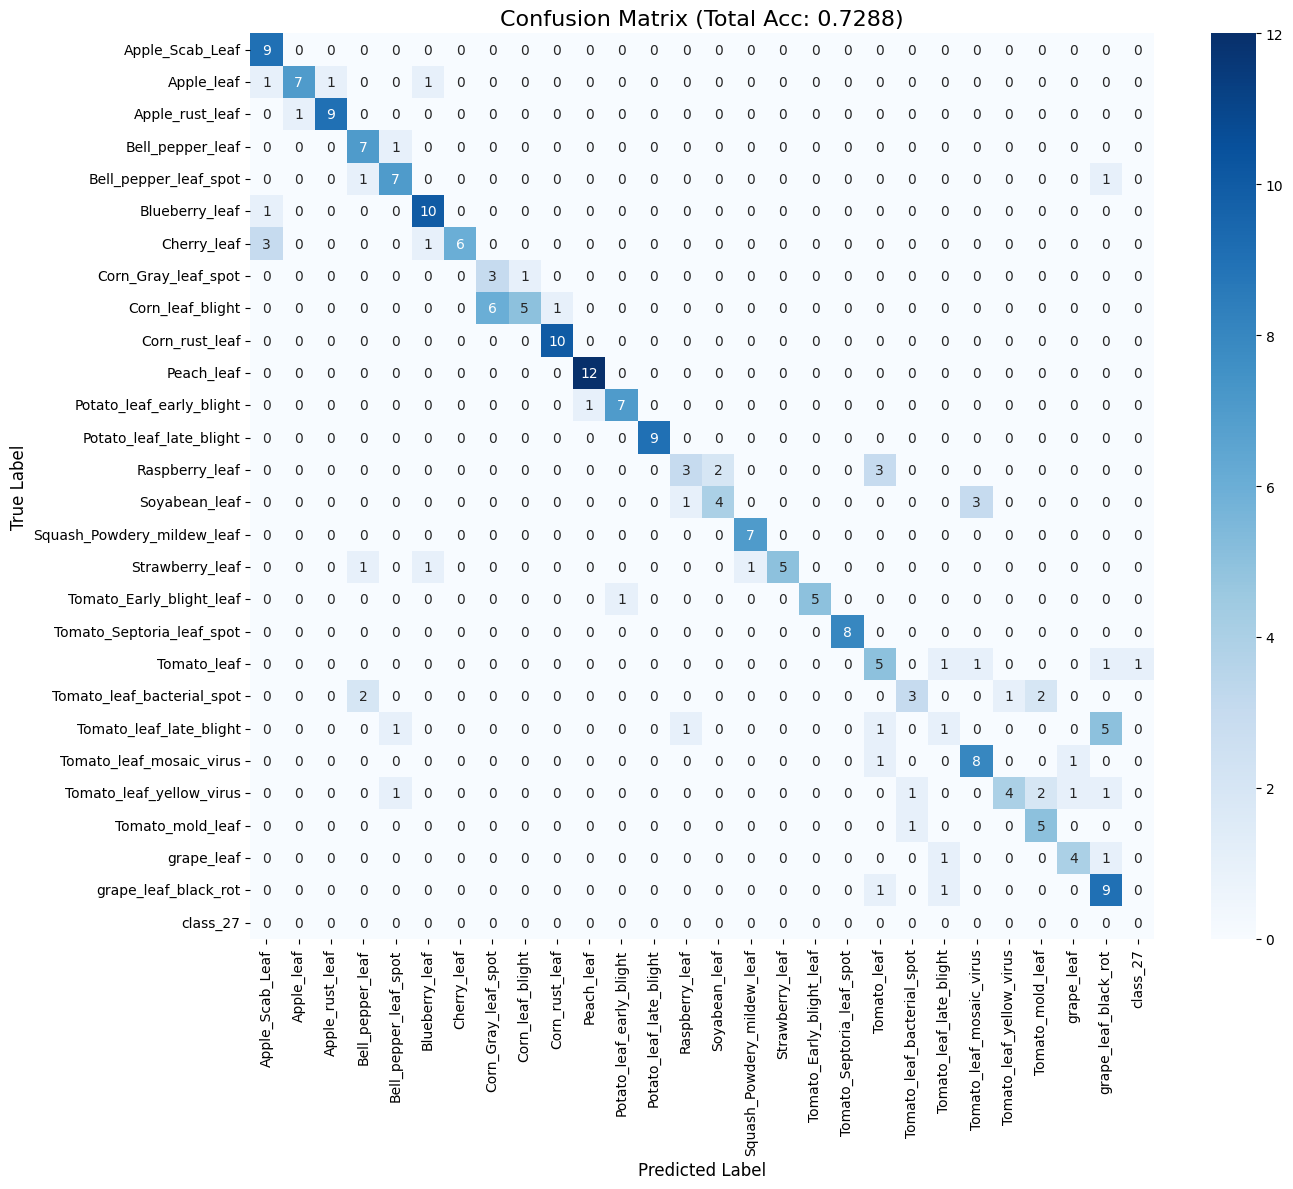

In [19]:
# Thực thi
metrics, y_pred, y_true = evaluate_model(model, val_loader, criterion, device)

idx_to_class = val_dataset.idx_to_class
labels = sorted(set(y_true) | set(y_pred))
target_names = [idx_to_class.get(i, f"class_{i}") for i in labels]

# 1) Point metrics từ hàm evaluate hiện có
print("\n" + "="*40)
print("VALIDATION METRICS SUMMARY")
print("="*40)
for k, v in metrics.items():
    print(f"{k.upper()}: {v:.4f}")

# 2) Class distribution để tái sử dụng giữa nhiều notebook validation
dist_rows = class_distribution_from_labels(y_true, idx_to_class)
print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)
print(f"{'Class':35s} {'Support':>8s} {'Ratio':>8s}")
for row in dist_rows:
    print(f"{row['class_name'][:35]:35s} {row['support']:8d} {row['ratio']*100:7.2f}%")

# 3) Macro-F1 / Balanced Accuracy + 95% CI (bootstrap)
boot = bootstrap_classification_metrics(y_true, y_pred, n_bootstrap=1000, ci_level=0.95, seed=42)
print("\n" + "="*60)
print("BOOTSTRAP METRICS (95% CI)")
print("="*60)
for name in ["accuracy", "macro_f1", "balanced_accuracy"]:
    point = boot["point"][name]
    lo = boot["ci"][name]["low"]
    hi = boot["ci"][name]["high"]
    print(f"{name:18s}: {point:.4f}  (95% CI: {lo:.4f} - {hi:.4f})")

# 4) Cảnh báo tự động khi support thấp
min_support = 5
warnings = low_support_warnings(dist_rows, min_support=min_support)
print("\n" + "="*60)
print(f"LOW SUPPORT CHECK (threshold < {min_support})")
print("="*60)
if warnings:
    for msg in warnings:
        print(msg)
else:
    print("No low-support classes detected.")

# 5) Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, labels=labels, target_names=target_names, digits=4, zero_division=0))

# 6) Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix (Total Acc: {metrics["accuracy"]:.4f})', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
